# AED — YouTube: léxico xenófobo y métricas

Análisis exploratorio del dataset recolectado (Práctica 6). Objetivo: caracterizar
la carga xenófoba (marcado de 2 capas `amplia`/`dirigida`) y sus métricas de
engagement en los comentarios de resúmenes del Mundial FIFA 2026.

> **Marcado = mismo código que el extractor.** Se importa `extractor_mundial.lexico`
> (fuente única de verdad). El match es por **substring** en minúsculas contra
> `config/lexico.txt` para capturar portmanteaus (`meximonos`, `latinsimio`,
> `mexisimio`), salvo los términos marcados `# exacto`, que exigen **límite de
> palabra** para no cobrar falsos positivos (`prieto`⊄*aprietos*, `singe`⊄*Kissinger*,
> `beur`⊄*bEuropeo*). Las menciones `@usuario` se descartan antes de marcar.
>
> Cada término lleva además un **eje** temático (anti-negro/simiesco, anti-mexicano/
> migrante, sudamericano/regional, colonial/autenticidad, anti-asiático), heredado
> de su sección en el léxico, para desglosar *qué tipo* de xenofobia domina.

> ⚠️ La columna `estrategia` del CSV refleja el marcado con el que se **recolectó**
> (léxico anterior). Aquí re-marcamos con el léxico vigente; por eso el conteo
> `dirigida` no tiene por qué coincidir con el del CSV.

In [1]:
import json, re
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
})
# Paleta apta para daltonismo: hue única (azul) para magnitud; naranja para resaltar 'dirigida'.
AZUL, NARANJA = "#4E79A7", "#F28E2B"
pd.set_option("display.max_colwidth", 90)

In [2]:
df = pd.read_csv("data/youtube.csv")
print(f"{len(df):,} comentarios cargados")
df.head(3)

372,178 comentarios cargados


,id,red,estrategia,criterio_busqueda,texto,idioma,autor,fecha_publicacion,url,metricas,fecha_extraccion
0,UgwLN4wFx6oQdAFFJdF4AaABAg,youtube,amplia,FRANCIA A SEMIS POR LOS GOLES DE MBAPPÉ Y DEMBÉLÉ | Francia 2-0 Marruecos | RESUMEN | M97,"Los franceses siguen con la musica elecrronica del 2000, raro estando en USA",NaN,@gxa528,2026-07-10T20:00:49.496611+00:00,https://www.youtube.com/watch?v=cvDfwQ9iKcs&lc=UgwLN4wFx6oQdAFFJdF4AaABAg,"{""likes"": ""0"", ""respuestas"": """", ""corazon_autor"": false}",2026-07-10T20:29:49.497260+00:00
1,UgydR6NL8jwm4dlgxvN4AaABAg,youtube,amplia,FRANCIA A SEMIS POR LOS GOLES DE MBAPPÉ Y DEMBÉLÉ | Francia 2-0 Marruecos | RESUMEN | M97,Bono 0 vs Francia 2,NaN,@Nico-pf3cg,2026-07-10T19:29:49.498381+00:00,https://www.youtube.com/watch?v=cvDfwQ9iKcs&lc=UgydR6NL8jwm4dlgxvN4AaABAg,"{""likes"": ""0"", ""respuestas"": """", ""corazon_autor"": false}",2026-07-10T20:29:49.498484+00:00
2,Ugyanbp8YndpllD9-zh4AaABAg,youtube,amplia,FRANCIA A SEMIS POR LOS GOLES DE MBAPPÉ Y DEMBÉLÉ | Francia 2-0 Marruecos | RESUMEN | M97,Tan fácil mejor uniera pasado brasil,NaN,@DavichoMedina-m1i,2026-07-10T19:29:49.499449+00:00,https://www.youtube.com/watch?v=cvDfwQ9iKcs&lc=Ugyanbp8YndpllD9-zh4AaABAg,"{""likes"": ""0"", ""respuestas"": """", ""corazon_autor"": false}",2026-07-10T20:29:49.499546+00:00


## 1. Preparación: métricas y marcado del léxico

El marcado usa **el mismo código que el extractor** (`extractor_mundial.lexico`):
substring + límite de palabra para los términos `exacto`, con menciones `@usuario`
descartadas. Reconstruimos por comentario los **términos** disparados y sus **ejes**.

In [3]:
def parse_num(x):
    """Convierte likes/respuestas ('1', '1.2K', '', NaN) a int."""
    s = str(x).strip().replace(",", "")
    if not s or s.lower() == "nan":
        return 0
    mult = 1
    if s[-1:].lower() == "k":
        mult, s = 1_000, s[:-1]
    elif s[-1:].lower() == "m":
        mult, s = 1_000_000, s[:-1]
    try:
        return int(float(s) * mult)
    except ValueError:
        return 0

m = df["metricas"].apply(json.loads)
df["likes"] = m.apply(lambda d: parse_num(d.get("likes")))
df["respuestas"] = m.apply(lambda d: parse_num(d.get("respuestas")))
df["corazon_autor"] = m.apply(lambda d: bool(d.get("corazon_autor")))

# Marcado con el MISMO código del extractor (fuente única de verdad).
from extractor_mundial.lexico import cargar as cargar_lexico

LEX = cargar_lexico(Path("config/lexico.txt"))
_disparos = df["texto"].apply(LEX.disparos)                       # list[Entrada] por comentario
df["terminos"] = _disparos.apply(lambda ds: [e.termino for e in ds])
df["ejes"] = _disparos.apply(lambda ds: sorted({e.eje for e in ds}))
df["dirigida"] = df["terminos"].str.len() > 0

n_ejes = len({e.eje for e in LEX.entradas})
print(f"léxico activo: {len(LEX.entradas)} términos en {n_ejes} ejes")
print(f"'dirigida' (marcado vigente): {df['dirigida'].sum()}  |  "
      f"'estrategia'=='dirigida' en CSV (léxico de recolección): "
      f"{(df['estrategia'] == 'dirigida').sum()}")

léxico activo: 104 términos en 6 ejes
'dirigida' (marcado vigente): 807  |  'estrategia'=='dirigida' en CSV (léxico de recolección): 715


## 2. Panorama general

In [5]:
pd.Series({
    "comentarios": len(df),
    "autores únicos": df["autor"].nunique(),
    "videos (criterios)": df["criterio_busqueda"].nunique(),
    "dirigida": int(df["dirigida"].sum()),
    "amplia": int((~df["dirigida"]).sum()),
    "% dirigida": round(100 * df["dirigida"].mean(), 3),
}, name="valor").to_frame()

,valor
comentarios,372178.000
autores únicos,175409.000
videos (criterios),384.000
dirigida,807.000
amplia,371371.000
% dirigida,0.217


## 3. El léxico xenófobo en los comentarios

¿Qué términos aparecen y con qué frecuencia?

In [6]:
freq = Counter()
for terms in df["terminos"]:
    freq.update(terms)

tab = pd.DataFrame(freq.most_common(), columns=["término", "comentarios"])
print(f"{len(freq)} términos distintos del léxico aparecen (de {len(LEX.entradas)} activos)")
tab.head(20)

47 términos distintos del léxico aparecen (de 104 activos)


,término,comentarios
0,monos,192
1,simio,108
2,sudaca,83
3,🐒,75
4,simios,62
5,sudacas,47
6,saltamuros,40
7,🦍,39
8,frijolero,35
9,colonizado,35


/tmp/ipykernel_23695/1649719244.py:9: UserWarning: Glyph 127820 (\N{BANANA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23695/1649719244.py:9: UserWarning: Glyph 129421 (\N{GORILLA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23695/1649719244.py:9: UserWarning: Glyph 128018 (\N{MONKEY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/felipep/Documentos/universidad/universidad 8vo/computacion_paralela/proyecto_final_ciclo/practica_06/.venv/lib/python3.14t/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127820 (\N{BANANA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/felipep/Documentos/universidad/universidad 8vo/computacion_paralela/proyecto_final_ciclo/practica_06/.venv/lib/python3.14t/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129421 (\N{GORILLA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/felipep/Document

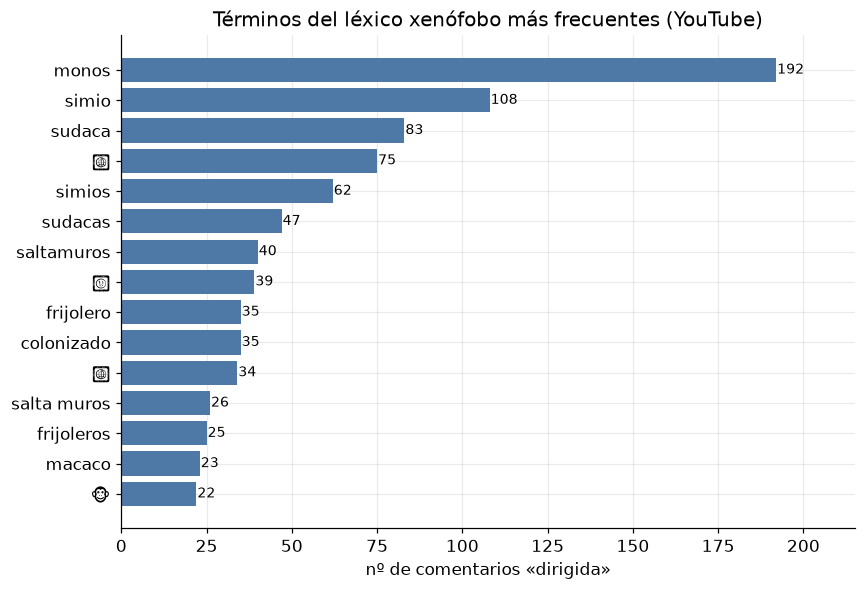

In [7]:
top = tab.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top["término"], top["comentarios"], color=AZUL)
for y, v in enumerate(top["comentarios"]):
    ax.text(v + 0.3, y, str(v), va="center", fontsize=9)
ax.set_title("Términos del léxico xenófobo más frecuentes (YouTube)")
ax.set_xlabel("nº de comentarios «dirigida»")
ax.margins(x=0.12)
plt.tight_layout()
plt.show()

### ¿Cómo se expresa el odio? (palabra / emoji / leet / frase)

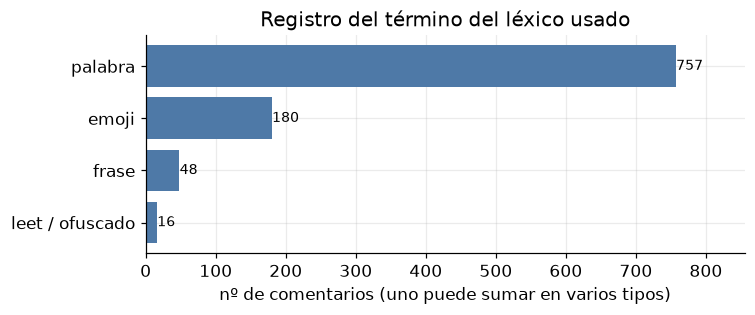

,comentarios
palabra,757
emoji,180
frase,48
leet / ofuscado,16


In [8]:
EMOJI = re.compile("[\U0001F000-\U0001FAFF\u2600-\u27BF\u2B00-\u2BFF\U0001F1E6-\U0001F1FF]")

def tipo_termino(t):
    if EMOJI.search(t):
        return "emoji"
    if any(c.isdigit() for c in t) or any(c in "@*!" for c in t) or re.search(r"\.\w", t):
        return "leet / ofuscado"
    if " " in t.strip():
        return "frase"
    return "palabra"

por_tipo = Counter()
for terms in df["terminos"]:
    for t in terms:
        por_tipo[tipo_termino(t)] += 1
serie_tipo = pd.Series(por_tipo).sort_values()

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(serie_tipo.index, serie_tipo.values, color=AZUL)
for y, v in enumerate(serie_tipo.values):
    ax.text(v + 0.5, y, str(v), va="center", fontsize=9)
ax.set_title("Registro del término del léxico usado")
ax.set_xlabel("nº de comentarios (uno puede sumar en varios tipos)")
ax.margins(x=0.13)
plt.tight_layout()
plt.show()
serie_tipo[::-1].to_frame("comentarios")

### Ejes del odio: ¿qué *tipo* de xenofobia domina?

Cada término del léxico está etiquetado con un **eje** temático. Esto separa el
registro *animalizador/antinegro* (Brasil, jugadores negros) del *anti-mexicano/
migrante* (tropo del muro), del *sudamericano/regional* (`sudaca`, `argie`) y del
*colonial/autenticidad* («no son franceses de verdad»).

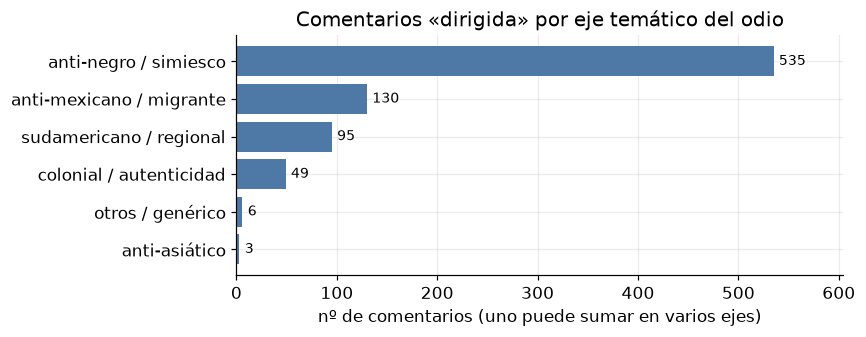

,comentarios
anti-negro / simiesco,535
anti-mexicano / migrante,130
sudamericano / regional,95
colonial / autenticidad,49
otros / genérico,6
anti-asiático,3


In [9]:
# Ejes del odio: ¿qué TIPO de xenofobia domina? (un comentario puede tocar varios ejes)
eje_counts = Counter()
for ejes in df["ejes"]:
    eje_counts.update(ejes)
serie_eje = pd.Series(eje_counts).sort_values()

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.barh(serie_eje.index, serie_eje.values, color=AZUL)
for y, v in enumerate(serie_eje.values):
    ax.text(v + max(serie_eje.values) * 0.01, y, str(v), va="center", fontsize=9)
ax.set_title("Comentarios «dirigida» por eje temático del odio")
ax.set_xlabel("nº de comentarios (uno puede sumar en varios ejes)")
ax.margins(x=0.13)
plt.tight_layout()
plt.show()
serie_eje[::-1].to_frame("comentarios")

## 4. Calidad del marcado: falsos positivos

El substring es potente (captura portmanteaus: `meximonos`, `mexisimio`, `latinsimio`)
pero cobra un precio cuando un término vive **dentro de palabras inocentes o nombres
propios**. El marcado vigente ya neutraliza **en origen** los peores casos:

| corrección | qué elimina | mecanismo |
|---|---|---|
| `# exacto` (límite de palabra) | `prieto`⊄*aprietos*/*Prieto*, `singe`⊄*Kissinger*, `beur`⊄*bEuropeo* | `\bpalabra\b` |
| descartar `@usuario` | apellidos/handles: `@…Prieto`, `@costazambo…` | quita menciones |

Lo que **queda** es el residual del substring que conservamos **a propósito** para no
perder portmanteaus: `monos`⊂*vámonos* y `simio`⊂*Simeone*. Abajo lo medimos y, para
que se vea el efecto de la corrección, comparamos contra el substring puro (sin
`exacto` ni quita de menciones) sobre el mismo léxico.

In [10]:
# --- Efecto de la corrección: substring puro vs. marcado vigente (exacto + sin @) ---
_low = df["texto"].astype(str).str.lower()
_terms_low = [e.termino.lower() for e in LEX.entradas]
substring_puro = _low.apply(lambda t: any(x in t for x in _terms_low))
n_puro, n_actual = int(substring_puro.sum()), int(df["dirigida"].sum())
print(f"dirigida con substring puro (léxico actual):   {n_puro}")
print(f"dirigida con marcado vigente (exacto + sin @):  {n_actual}")
print(f"  → la corrección descartó {n_puro - n_actual} comentarios de puro ruido "
      f"(prieto/aprietos, Kissinger, bEuropeo, @usuarios)\n")

# --- Residual del substring que se conserva a propósito (monos/simio) ---
MONOS_FP = re.compile(
    r"\b(v[aá]monos|qued[eé]monos|imagin[eé]monos|ri[aá]monos|vay[aá]monos|"
    r"dig[aá]monos|hag[aá]monos|ve[aá]monos|pong[aá]monos|olvid[eé]monos|"
    r"sent[eé]monos|largu[eé]monos|call[eé]monos)\b",
    re.I,
)

def es_fp(term, texto):
    """True si ESTE disparo es ruido residual (palabra inocente / nombre propio)."""
    t = str(texto).lower()
    if term == "monos":
        tiene_slur = bool(re.search(r"\bmonos?\b", t)) or "meximonos" in t
        return bool(MONOS_FP.search(t)) and not tiene_slur
    if term == "simio":                       # Simeone / Simione (el DT)
        return ("simione" in t or "simeone" in t) and "simios" not in t and t.count("simio") <= 1
    return False

dg = df[df["dirigida"]].copy()
# Un comentario es ruido solo si TODOS los términos que disparó son FP.
dg["ruido"] = dg.apply(lambda r: all(es_fp(term, r["texto"]) for term in r["terminos"]), axis=1)

fp_por_term, tot_por_term = Counter(), Counter()
for _, r in dg.iterrows():
    for term in r["terminos"]:
        tot_por_term[term] += 1
        if es_fp(term, r["texto"]):
            fp_por_term[term] += 1

tabla_fp = (pd.DataFrame({"total": tot_por_term, "falsos_positivos": fp_por_term})
            .fillna(0).astype(int))
tabla_fp["% ruido"] = (100 * tabla_fp["falsos_positivos"] / tabla_fp["total"]).round(0)
tabla_fp = tabla_fp[tabla_fp["falsos_positivos"] > 0].sort_values("falsos_positivos", ascending=False)

n, ruido = len(dg), int(dg["ruido"].sum())
print(f"comentarios «dirigida» (marcado vigente): {n}")
print(f"  ruido residual (todos sus términos FP): {ruido}")
print(f"  xenofobia real (probable):              {n - ruido}")
print(f"  PRECISIÓN a nivel comentario:           {100 * (n - ruido) / n:.1f}%\n")
print("Falsos positivos residuales por término:")
tabla_fp

dirigida con substring puro (léxico actual):   865
dirigida con marcado vigente (exacto + sin @):  807
  → la corrección descartó 58 comentarios de puro ruido (prieto/aprietos, Kissinger, bEuropeo, @usuarios)

comentarios «dirigida» (marcado vigente): 807
  ruido residual (todos sus términos FP): 47
  xenofobia real (probable):              760
  PRECISIÓN a nivel comentario:           94.2%

Falsos positivos residuales por término:


,total,falsos_positivos,% ruido
monos,192,40,21.0
simio,108,7,6.0


## 5. Métricas de engagement

¿El comentario xenófobo recibe más o menos likes que el resto?

In [11]:
etiqueta = df["dirigida"].map({True: "dirigida", False: "amplia"})
eng = df.groupby(etiqueta)["likes"].agg(n="count", media="mean", mediana="median", maximo="max")
eng

,n,media,mediana,maximo
dirigida,,,,
amplia,371371,8.336057,0.0,15000
dirigida,807,3.340768,0.0,1700


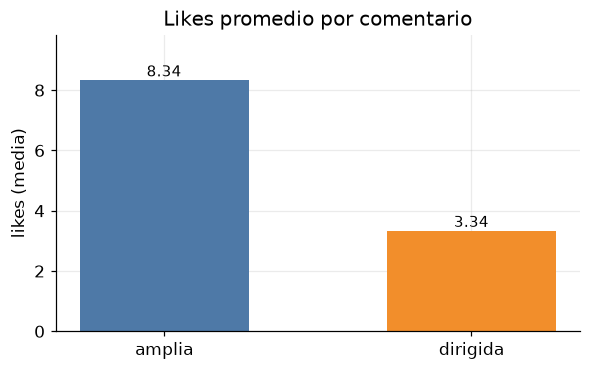

In [12]:
medias = eng["media"]
fig, ax = plt.subplots(figsize=(5.5, 3.5))
colores = [NARANJA if i == "dirigida" else AZUL for i in medias.index]
ax.bar(medias.index, medias.values, color=colores, width=0.55)
for x, v in enumerate(medias.values):
    ax.text(x, v, f"{v:.2f}", ha="center", va="bottom", fontsize=10)
ax.set_title("Likes promedio por comentario")
ax.set_ylabel("likes (media)")
ax.margins(y=0.18)
plt.tight_layout()
plt.show()

## 6. Concentración por video (evento gatillo)

¿En qué partidos se dispara el odio?

In [13]:
por_video = df.groupby("criterio_busqueda")["dirigida"].agg(dirigida="sum", total="count")
por_video["% dirigida"] = (100 * por_video["dirigida"] / por_video["total"]).round(2)
top_v = por_video.sort_values("dirigida", ascending=False).head(8)
top_v

,dirigida,total,% dirigida
criterio_busqueda,,,
#ENGLAND ELIMINATED #MEXICO IN A THRILLING MATCH AT THE AZTECA! | Mexico 2–3 England | Highlights,94,5000,1.88
¡AFUERA MÉXICO! INGLATERRA LO AGUANTÓ CON 10 Y ESTÁ EN 4tos | México 2-3 Inglaterra | RESUMEN | M92,53,3860,1.37
#ECUADOR OUT OF THE WORLD CUP! FELL to #MEXICO in a HEATED MATCH | Mexico 2–0 Ecuador | Highlights,39,3842,1.02
WHAT WOULD FRANCE BE WITHOUT AFRICA? DEBATE AND REACTION - 2026 WORLD CUP,25,2607,0.96
¡#NORUEGA ELIMINÓ A #BRASIL con un DOBLETE de #HAALAND! | Brasil 1–2 Noruega | Resumen,24,4838,0.50
#ECUADOR STUNS #GERMANY WITH A COMEBACK WIN!! | Ecuador 2–1 Germany | Highlights,19,5000,0.38
ECUADOR TUVO DOS TRAVESAÑOS Y LO PERDIÓ EN EL FINAL | Costa de Marfil 1-0 Ecuador | RESUMEN | M11,17,3062,0.56
HISTÓRICA VICTORIA DE ECUADOR DE BECCACECE PARA CLASIFICAR | Ecuador 2-1 Alemania | RESUMEN | M55,16,3725,0.43


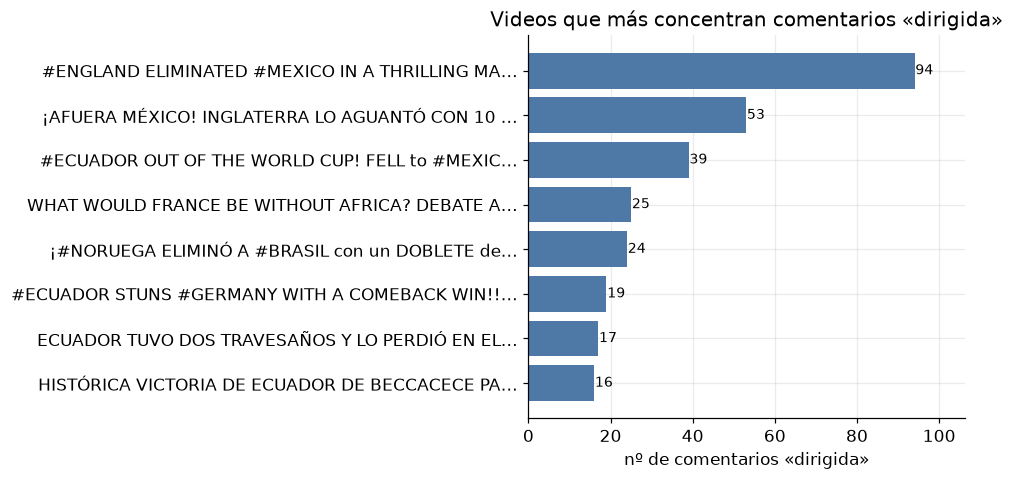

In [14]:
tv = top_v.iloc[::-1]
etiquetas = [c[:45] + "…" if len(c) > 45 else c for c in tv.index]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(etiquetas, tv["dirigida"], color=AZUL)
for y, v in enumerate(tv["dirigida"]):
    ax.text(v + 0.2, y, str(int(v)), va="center", fontsize=9)
ax.set_title("Videos que más concentran comentarios «dirigida»")
ax.set_xlabel("nº de comentarios «dirigida»")
ax.margins(x=0.13)
plt.tight_layout()
plt.show()

## 7. Muestras de comentarios «dirigida» (top por likes)

In [15]:
(df[df["dirigida"]]
 .sort_values("likes", ascending=False)[["texto", "terminos", "likes", "respuestas"]]
 .head(15)
 .reset_index(drop=True))

,texto,terminos,likes,respuestas
0,Acostumbrémonos a no llamar pausa de hidratación a la pausa publicitaria.,[monos],1700,39
1,Perdió la banana mecánica 🍌 pero ganó el fútbol 🇲🇽,[🍌],451,3
2,"Estamos en el último baile de estos dos fenómenos, alegrémonos de qué les vaya bien, c...",[monos],55,1
3,Mi Colombia está para cosas grandes (podemos ser campeones ilusionenmonos💛❤️💙,[monos],44,3
4,"🫠🫠🫠Nos dicen monos, incivilizados sin conocer nuestra situación, burros, feos, indios ...",[monos],17,0
5,"Vini está haciendo un gran mundial, si hacía ese gol era apague y vamonos",[monos],14,0
6,INGLATERRA SALVO EL FUTBOL LA HUMANIDAD EL DEPORTE LA CIVILIZACION...QUE VIOLADA QUE L...,[saltamuros],14,0
7,​ @JuanPerez-bs6ic Si Portugal no tiene jerarquía ofensiva entonces apaga y vámonos. Q...,[monos],12,0
8,"Davoo, acá desde Brasil, te cuento: sospecho que estamos viviendo una época muy extrañ...","[colonizado, colonizada, colonizados]",12,2
9,"Hay momento para todo. Tampoco neguémonos las ganas de celebrar. Festejemos, soñemos y...",[monos],12,0


## Hallazgos

> Dataset completo (al 14-jul-2026, tras la recolección **dirigida al canal Davoo
> Xeneize**): **372,178 comentarios**, **175,409 autores** únicos, **384 videos**
> (playlists ESPN + DS Sports **+ 75 videos del canal de reacción Davoo Xeneize**).
> Frente al corte nocturno (270,168 com. / 309 videos), el canal de reacción aportó
> **+102,010 comentarios** y **+75 videos**. Léxico **v2**: 104 términos en **6 ejes**,
> marcado compartido con el extractor.

- **La hipótesis del canal de reacción se confirma en el eje colonial.** Davoo es un
  canal de *reacciones* (no highlights neutros): más debate, humor y rabia. El efecto
  se ve nítido en el **eje colonial/autenticidad, que se DUPLICÓ (22 → 49)**, empujado
  por el video **«What would France be without Africa? — Debate and Reaction»** (25
  comentarios `dirigida` él solo, top-4 del dataset). `colonizado` saltó de 12 → 35.
  El registro *«no son franceses de verdad»* / *«país colonizado»* que en las playlists
  de resúmenes apenas asomaba, en un canal de debate aflora con fuerza.

- **Volumen y señal:** la capa `dirigida` es **807 comentarios (0.217 %)**. Frente al
  corte anterior (693) el neto es **+114**, casi todos del canal de reacción. La tasa
  baja levemente (0.26 % → 0.217 %) porque Davoo también aporta muchísimo comentario
  neutro de fanático; el odio explícito sigue siendo cola larga.

- **La corrección del matching se mantiene — precisión 94.2 %.** El marcado por
  **límite de palabra** (`# exacto`) + **descartar menciones `@usuario`** descarta en
  origen **58** comentarios de puro ruido (`prieto`⊂*aprietos*, `singe`⊂*Kissinger*,
  `beur`⊂*bEuropeo*, handles). El **ruido residual** es **47 de 807 (precisión 94.2 %)**
  y es *solo* el substring que conservamos a propósito para portmanteaus: `monos`⊂*vámonos*
  (40) y `simio`⊂*Simeone* (7). Es el precio consciente de capturar `meximonos`/`mexisimio`.

- **Registro dominante = animalización racista (eje anti-negro: 535 comentarios).**
  `monos` (192), `simio`/`simios` (170), `macaco` (23), `gorila` (15) y los emojis
  🐒 (75) 🦍 (39) 🍌 (34) 🐵 (22) siguen liderando. Blanco principal: Brasil/Vinícius
  («sopa de macaco») y México/Ecuador («meximonos», «mexisimios»).

- **El eje anti-mexicano/migrante se mantiene como segundo eje real (130 comentarios).**
  El registro del **muro fronterizo** —`saltamuros` (40), `salta muros` (26),
  `trepamuros` (20)— y `frijolero`/`frijoleros` (60) capturan una xenofobia que el
  léxico simiesco NO veía: *«Afuera los saltamuros»*, *«A llorar frijoleros»*. Es el
  ángulo *contexto Trump/ICE 2026* del informe, hecho dato.

- **Tercer y cuarto eje:** sudamericano/regional (`sudaca`/`sudacas` + `argie` = 95) y
  colonial/autenticidad (49, ver arriba). Conviven el ataque racial, el regional y el
  de *negar la pertenencia nacional* — conflicto interétnico multi-frente.

- **El emoji como hate speech implícito:** **180** disparos son de emoji (🐒/🦍/🍌/🐵),
  muchos sin ninguna palabra, con respaldo del fallo del Meta Oversight Board (feb-2026)
  y del dato PFA/Signify (56 % de posts racistas usan emoji). Refuerza el gancho *humor/
  emoji como vehículo del odio*, difícil de moderar y de clasificar.

- **Engagement — el dato se movió con el canal de reacción.** Los `dirigida` reciben
  **~2.5× menos likes** de media (**3.34** vs **8.34** de `amplia`), no los ~15× del
  corte previo de solo highlights. La audiencia de un canal de *debate* premia bastante
  más el comentario cargado (algunos superan 1000 likes), lo que encaja con la hipótesis:
  la reacción da tribuna al odio que en un resumen neutro moría en la cola.

- **Evento gatillo confirmado:** el odio se concentra en **eliminaciones/derrotas de
  México, Ecuador y Brasil** (México 2-3 Inglaterra = 94 + 53 `dirigida`, México 2-0
  Ecuador, Brasil 1-2 Noruega). El resultado adverso dispara el ataque hacia el país
  perdedor.

**Conclusión honesta:** con Davoo el dataset gana **+102 k comentarios** y una veta
clara del eje **colonial** que las playlists de resúmenes no daban. El léxico v2
mantiene **94 % de precisión**. Aun así, `dirigida` (807) sigue siendo un **filtro de
recall alto para pre-etiquetar**, no una etiqueta final: queda (a) el residual consciente
de `monos`/`simio`, y (b) todo el registro *codificado* que describe el informe (ironía,
«animal/bruto», tropos coloniales sutiles) que **el substring no puede ver** y es tarea
del modelo de la Práctica 7. A 807 comentarios, la revisión manual sigue siendo
perfectamente auditable antes de entrenar.